<a href="https://colab.research.google.com/github/muhamadr03/Praktikum-ML/blob/main/Praktikum%20Mandiri%2012/PraktikumMandiri12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Konfigurasi plot
plt.rcParams['figure.figsize'] = (8, 6)

In [16]:
# 1 load dataset
df = pd.read_csv('/content/drive/MyDrive/Praktikum ML/Praktikum Mandiri/data/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# 2 preprocessing
# Menghapus kolom yang tidak perlu
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Encoding target (M -> 1, B -> 0)
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
target_names = le.classes_ # ['B', 'M']

# EDA Singkat
print("Info Dataset:")
print(df.info())
print("\nJumlah per Kelas:")
print(df['diagnosis'].value_counts())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se     

In [5]:
# 3. Split Features dan Target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# 4. Standardisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# 5. Model SVM Tanpa PCA
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_no_pca.fit(X_train_scaled, y_train)

y_pred_no_pca = svm_no_pca.predict(X_test_scaled)
acc_no_pca = accuracy_score(y_test, y_pred_no_pca)

print(f"\n=== Akurasi tanpa PCA: {acc_no_pca:.4f} ===")
print(classification_report(y_test, y_pred_no_pca, target_names=['B', 'M']))


=== Akurasi tanpa PCA: 0.9737 ===
              precision    recall  f1-score   support

           B       0.96      1.00      0.98        72
           M       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



Total variansi (3 komponen): 0.7272


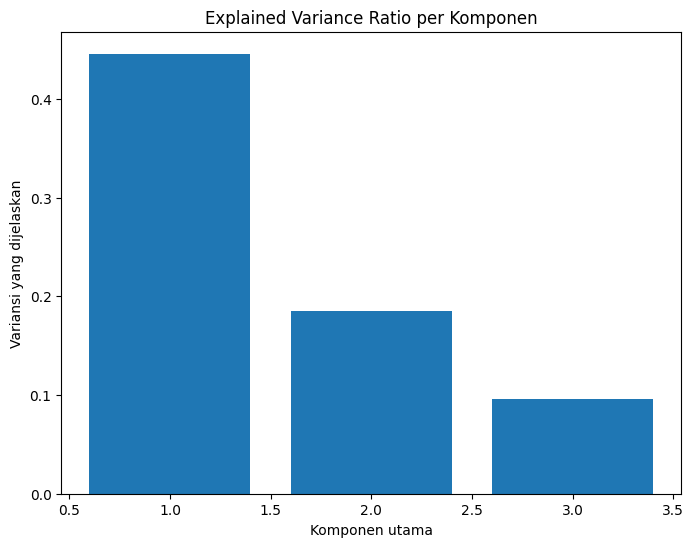

In [11]:
# 6. Penerapan PCA (3 Komponen)
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Explained Variance
explained_var = pca.explained_variance_ratio_
print(f"Total variansi (3 komponen): {explained_var.sum():.4f}")

# Plot Explained Variance
plt.figure()
plt.bar([1, 2, 3], explained_var)
plt.xlabel("Komponen utama")
plt.ylabel("Variansi yang dijelaskan")
plt.title("Explained Variance Ratio per Komponen")
plt.show()

In [13]:
# 7. Model SVM Dengan PCA
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
svm_pca.fit(X_train_pca, y_train)

y_pred_pca = svm_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

print(f"\n=== Akurasi dengan PCA: {acc_pca:.4f} ===")
print(classification_report(y_test, y_pred_pca, target_names=['B', 'M']))


=== Akurasi dengan PCA: 0.9561 ===
              precision    recall  f1-score   support

           B       0.94      1.00      0.97        72
           M       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



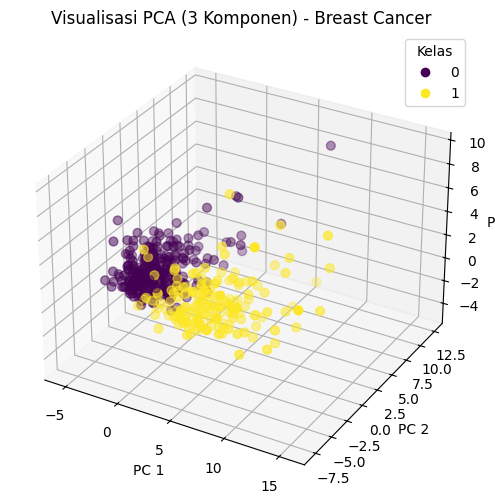

In [14]:
# 8. Visualisasi 3D PCA
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2],
    c=y_train, cmap='viridis', s=40
)

ax.set_title('Visualisasi PCA (3 Komponen) - Breast Cancer')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_zlabel('PC 3')
ax.legend(*scatter.legend_elements(), title="Kelas")
plt.show()

In [15]:
# 9. Perbandingan
comparison = pd.DataFrame({
    'Model': ['SVM tanpa PCA', 'SVM dengan PCA'],
    'Jumlah Fitur': [X_train_scaled.shape[1], X_train_pca.shape[1]],
    'Akurasi': [acc_no_pca, acc_pca]
})
print("\nPerbandingan Model:")
print(comparison)


Perbandingan Model:
            Model  Jumlah Fitur   Akurasi
0   SVM tanpa PCA            30  0.973684
1  SVM dengan PCA             3  0.956140
